# Calidad de Datos y Modelos de Clasificación - Accidentes de Tránsito en Bucaramanga (Comuna Centro, 2017)

**Problema:** predecir si un accidente de tránsito en la Comuna Centro de Bucaramanga termina **con víctimas** (heridos o muertos) o **solo con daños materiales**, a partir de las características del accidente (mes, día, hora, jornada, barrio, propietario del vehículo y número de automóviles y motos involucrados).

**Datos:** accidentes de tránsito publicados por la Secretaría de Tránsito de Bucaramanga en datos.gov.co (39.193 registros de 2012 a 2023), filtrados a la Comuna 15 - Centro en 2017 (406 registros).

**Cómo está organizado el notebook:** las secciones 1 a 8 preparan y entienden los datos (calidad de datos); la 9 decide qué variables usar; la 10 las transforma; las 11 a 13 construyen, comparan y optimizan los modelos; y la 14 evalúa y guarda el modelo final.

1. Integración de los datos
2. Eliminar variables irrelevantes y redundantes
3. Descripción estadística de los datos
4. Limpieza de datos atípicos-errores
5. Limpieza de datos nulos: Imputación
6. Correlaciones para redundancias
7. Correlaciones para irrelevancia con la variable objetivo
8. Variable objetivo y balanceo
9. **Selección de factores**
10. Transformaciones (Dummies, LabelEncoder)
11. **Modelo predictivo con validación cruzada** (Árbol, Random Forest, XGBoost, KNN, Red Neuronal, SVM) y revisión de overfitting / underfitting
12. **Comparación de modelos y conclusiones**
13. **Hiperparametrización del mejor modelo con GridSearchCV**
14. Evaluación final y guardado del modelo

* El despliegue con interfaz gráfica se realiza en otro jupyter notebook

In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Integración de Datos

**Qué es y para qué sirve.** Integrar datos es reunir en una sola tabla la información que viene de distintas fuentes (por ejemplo, con un `merge` por una llave común). El objetivo es partir de una tabla en la que cada fila representa un solo caso y nada se repite ni se pierde.

A diferencia del ejemplo de Empleados (que integraba dos tablas por medio de un `merge`), esta base ya viene consolidada en un único archivo publicado por la Secretaría de Tránsito de Bucaramanga. Aun así, se revisa la integridad del identificador (`ORDEN`) antes de continuar: si hubiera `ORDEN` repetidos, habría accidentes duplicados.

**Filtrado del dataset original.** El archivo publicado en datos.gov.co trae el histórico completo del municipio (todas las comunas, 2012-2023). Para tener un conjunto de datos manejable y que cumpla el mínimo solicitado por la práctica (400 registros), se filtra a la **Comuna 15 - Centro** y al **año 2017**. El proceso completo, desde el archivo original, queda documentado a continuación.

**Qué hacen las celdas siguientes:** cargan el archivo completo, muestran cuántos accidentes hay por comuna y por año (para decidir el filtro con datos), aplican el filtro y verifican que no haya identificadores repetidos.

In [2]:
# Se carga el archivo ORIGINAL COMPLETO tal como se descarga de datos.gov.co
data_completa = pd.read_csv("accidentes_bucaramanga_completo.csv", engine='python')
print("Registros y columnas del dataset original completo:", data_completa.shape)
data_completa.head()

Registros y columnas del dataset original completo: (39193, 24)


,ORDEN,FECHA,AÑO,MES,DÍA,GRAVEDAD,PEATON,AUTOMOVIL,CAMPERO,CAMIONETA,...,VOLQUETA,MOTO,BICICLETA,OTRO,BARRIO,HORA,ENTIDAD,COMUNA,Propietario de Vehículo,DIURNIO/NOCTURNO
0,1,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Con heridos,0,1,0,0,...,0,0,0,0,Mutis,1899-12-31T12:15:00.000,AGENTES DTB,17. MUTIS,Particular,Diurno
1,2,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,1,0,1,...,0,0,0,0,Regaderos Norte,1899-12-31T14:00:00.000,AGENTES DTB,02. NORORIENTAL,Empresa,Diurno
2,3,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,0,0,1,...,0,0,0,0,Cabecera Del Llano,1899-12-31T12:00:00.000,AGENTES DTB,12. CABECERA DEL LLANO,Particular,Diurno
3,4,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,1,0,1,...,0,0,0,0,Norte Bajo,1899-12-31T18:30:00.000,AGENTES DTB,03. SAN FRANCISCO,Empresa,Nocturno
4,5,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Con heridos,1,0,0,0,...,0,1,0,0,Dangond,1899-12-31T00:30:00.000,AGENTES DTB,11. SUR,Particular,Nocturno


In [3]:
# Exploramos las comunas y años disponibles para decidir el filtro
print(data_completa['COMUNA'].value_counts())
print()
print(data_completa['AÑO'].value_counts().sort_index())

COMUNA
12. CABECERA DEL LLANO    6415
03. SAN FRANCISCO         5287
13. ORIENTAL              5093
15. CENTRO                4405
06. LA CONCORDIA          3180
10. PROVENZA              2421
04. OCCIDENTAL            2143
NO DISPONIBLE             1553
05. GARCIA ROVIRA         1517
01. NORTE                 1209
09. LA PEDREGOSA          1188
07. LA CIUDADELA           861
16. LAGOS DEL CACIQUE      806
11. SUR                    716
17. MUTIS                  693
08. SUR OCCIDENTE          612
02. NORORIENTAL            535
14. MORRORICO              420
CORREG. 1                   83
CORREG. 3                   55
CORREG. 2                    1
Name: count, dtype: int64

AÑO
2012    4342
2013    4054
2014    3724
2015    3765
2016    3739
2017    3812
2018    3917
2019    3716
2020    2261
2021    2719
2022    2220
2023     924
Name: count, dtype: int64


In [4]:
# Filtramos a la Comuna 15 - Centro, año 2017
data = data_completa[(data_completa['COMUNA'] == '15. CENTRO') &
                      (data_completa['AÑO'] == 2017)].copy()

print("Registros y columnas después del filtro:", data.shape)
data.head()

Registros y columnas después del filtro: (406, 24)


,ORDEN,FECHA,AÑO,MES,DÍA,GRAVEDAD,PEATON,AUTOMOVIL,CAMPERO,CAMIONETA,...,VOLQUETA,MOTO,BICICLETA,OTRO,BARRIO,HORA,ENTIDAD,COMUNA,Propietario de Vehículo,DIURNIO/NOCTURNO
19647,19648,2017-01-04T00:00:00.000,2017,01. Enero,03. Miercoles,Solo daños,0,1,0,1,...,0,0,0,0,Garcia Rovira,1899-12-31T21:40:00.000,AGENTES DTB,15. CENTRO,Particular,Nocturno
19661,19662,2017-01-06T00:00:00.000,2017,01. Enero,05. Viernes,Con heridos,0,1,0,0,...,0,1,0,0,Centro,1899-12-31T12:45:00.000,AGENTES DTB,15. CENTRO,Empresa,Diurno
19668,19669,2017-01-08T00:00:00.000,2017,01. Enero,07. Domingo,Con heridos,0,1,0,0,...,0,1,0,0,Garcia Rovira,1899-12-31T19:20:00.000,AGENTES DTB,15. CENTRO,Empresa,Nocturno
19670,19671,2017-01-09T00:00:00.000,2017,01. Enero,01. Lunes,Solo daños,0,0,0,1,...,0,1,0,0,Centro,1899-12-31T14:30:00.000,AGENTES DTB,15. CENTRO,Empresa,Diurno
19678,19679,2017-01-10T00:00:00.000,2017,01. Enero,02. Martes,Solo daños,0,0,0,0,...,0,1,0,0,Centro,1899-12-31T13:15:00.000,AGENTES DTB,15. CENTRO,Empresa,Diurno


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406 entries, 19647 to 23430
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ORDEN                    406 non-null    int64 
 1   FECHA                    406 non-null    object
 2   AÑO                      406 non-null    int64 
 3   MES                      406 non-null    object
 4   DÍA                      406 non-null    object
 5   GRAVEDAD                 406 non-null    object
 6   PEATON                   406 non-null    int64 
 7   AUTOMOVIL                406 non-null    int64 
 8   CAMPERO                  406 non-null    int64 
 9   CAMIONETA                406 non-null    int64 
 10  MICRO                    406 non-null    int64 
 11  BUSETA                   406 non-null    int64 
 12  BUS                      406 non-null    int64 
 13  CAMION                   406 non-null    int64 
 14  VOLQUETA                 406 non-null    

In [6]:
#Revisamos si tenemos ID (ORDEN) repetidos
ids = data['ORDEN'].value_counts()
ids[ids > 1]

,count
ORDEN,


No hay identificadores repetidos, por lo tanto no hay registros duplicados que eliminar. La integración se da por completa.

**Resultado de la sección:** del archivo original (39.193 registros y 24 columnas) se pasa a **406 registros y 24 columnas**, que corresponden a los accidentes de la Comuna Centro en 2017 (de los 4.405 que esa comuna tiene en todo el periodo). Todos los análisis siguientes se hacen sobre estos 406 accidentes.

# 2. Eliminar variables irrelevantes y redundantes

Antes de analizar los datos conviene quitar las columnas que no ayudan a predecir o que repiten información, porque solo agregan ruido y hacen más lento y menos estable el análisis.

* **Irrelevantes:** identificadores (cada fila tiene uno distinto, así que no dicen nada sobre la gravedad), variables **constantes** (si todas las filas tienen el mismo valor, no distinguen un accidente de otro) y variables con muy poca variabilidad.
* **Redundantes:** variables que repiten la misma información que ya está en otra columna.

Al filtrar el dataset original a una sola comuna y un solo año, las columnas `AÑO` y `COMUNA` quedan **constantes** (todas las filas tienen el mismo valor), por lo que dejan de aportar información y se consideran irrelevantes en este subconjunto. La celda siguiente lo verifica mostrando los valores únicos de cada una.

In [7]:
# Verificamos que AÑO y COMUNA quedaron constantes tras el filtro
print(data['AÑO'].unique())
print(data['COMUNA'].unique())
print(data['ENTIDAD'].unique())
print(data['VOLQUETA'].unique())

[2017]
['15. CENTRO']
['AGENTES DTB']
[0]


**Variables irrelevantes identificadas:**
- `ORDEN`: identificador de fila, no aporta valor predictivo.
- `AÑO` y `COMUNA`: quedaron constantes tras el filtro (todas 2017 / Centro).
- `ENTIDAD`: constante, el 100% de los registros fueron reportados por "AGENTES DTB".
- `VOLQUETA`: constante en cero, ningún accidente de este subconjunto involucró volquetas.
- `PEATON`, `CAMPERO`, `CAMIONETA`, `MICRO`, `BUSETA`, `BUS`, `CAMION`, `BICICLETA`, `OTRO`: columnas de conteo de peatones y de otros tipos de vehículo. **No son constantes**: en este subconjunto aparecen con valores distintos de cero en `PEATON` 16.3 %, `CAMIONETA` 15.8 %, `BUSETA` 8.1 %, `CAMION` 6.9 %, `BUS` 3.7 %, `CAMPERO` 3.2 %, `MICRO` 1.5 %, `BICICLETA` 0.7 % y `OTRO` 0.5 % de los accidentes. Se dejan por fuera del análisis por una **decisión de alcance**: trabajar con las 8 variables predictoras de este proyecto (`Mes`, `Dia`, `Hora`, `Jornada`, `Barrio`, `Propietario`, `Automovil`, `Moto`). Esto es una limitación del proyecto: `PEATON` y `CAMIONETA` tienen una frecuencia apreciable y podrían incorporarse en una versión posterior del modelo.

**Variable redundante identificada:**
- `FECHA`: es matemáticamente redundante porque toda su información (año, mes y día) ya está contenida por separado en las columnas `AÑO`, `MES` y `DÍA`.
- `HORA` (texto original con fecha ficticia 1899-12-31): se reemplaza por la hora numérica extraída `Hora`, por lo que la columna de texto original es redundante una vez hecha la extracción.

**Resultado:** el conjunto queda con **9 columnas**: las 8 predictoras y la variable objetivo `Gravedad`. Además, `Mes`, `Dia`, `Jornada`, `Barrio` y `Propietario` se convierten a tipo `category`, para que Python las trate como categorías y no como texto libre.

In [8]:
# Extraemos la hora como variable numérica (0-23) a partir del texto original de HORA
data['Hora'] = pd.to_datetime(data['HORA']).dt.hour

# Seleccionamos las 8 variables predictoras + la variable objetivo
columnas_finales = ['MES','DÍA','Hora','DIURNIO/NOCTURNO','BARRIO',
                     'Propietario de Vehículo','AUTOMOVIL','MOTO','GRAVEDAD']
data = data[columnas_finales].copy()
data.columns = ['Mes','Dia','Hora','Jornada','Barrio','Propietario','Automovil','Moto','Gravedad']
data.head()

,Mes,Dia,Hora,Jornada,Barrio,Propietario,Automovil,Moto,Gravedad
19647,01. Enero,03. Miercoles,21,Nocturno,Garcia Rovira,Particular,1,0,Solo daños
19661,01. Enero,05. Viernes,12,Diurno,Centro,Empresa,1,1,Con heridos
19668,01. Enero,07. Domingo,19,Nocturno,Garcia Rovira,Empresa,1,1,Con heridos
19670,01. Enero,01. Lunes,14,Diurno,Centro,Empresa,0,1,Solo daños
19678,01. Enero,02. Martes,13,Diurno,Centro,Empresa,0,1,Solo daños


In [9]:
#Corrección del tipo de datos object a categorías
data['Mes']=data['Mes'].astype('category')
data['Dia']=data['Dia'].astype('category')
data['Jornada']=data['Jornada'].astype('category')
data['Barrio']=data['Barrio'].astype('category')
data['Propietario']=data['Propietario'].astype('category')
data['Gravedad']=data['Gravedad'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406 entries, 19647 to 23430
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Mes          406 non-null    category
 1   Dia          406 non-null    category
 2   Hora         406 non-null    int32   
 3   Jornada      406 non-null    category
 4   Barrio       406 non-null    category
 5   Propietario  406 non-null    category
 6   Automovil    406 non-null    int64   
 7   Moto         406 non-null    int64   
 8   Gravedad     406 non-null    category
dtypes: category(6), int32(1), int64(2)
memory usage: 14.7 KB


# 3. Descripción estadística

**Para qué sirve.** Antes de modelar hay que conocer los datos: en qué rango se mueven las variables numéricas, cuántas categorías tienen las categóricas y cómo se reparten. Aquí se usan `describe()` (resumen numérico), histogramas y boxplots (forma de la distribución y valores extremos), gráficos de barras (frecuencia de cada categoría), una matriz de dispersión (relación entre variables numéricas) y un perfilado automático con `ydata-profiling`.

**Variable objetivo:** `Gravedad` (Solo daños / Con heridos / Con muertos)

**Variables predictoras (8):** `Mes`, `Dia`, `Hora`, `Jornada`, `Barrio`, `Propietario`, `Automovil`, `Moto`

**Variables numéricas**

In [10]:
#Conocemos un poco los datos numéricos
data.describe()

,Hora,Automovil,Moto
count,406.000000,406.000000,406.000000
mean,13.256158,0.748768,0.655172
std,4.911905,0.674719,0.639684
min,0.000000,0.000000,0.000000
25%,9.250000,0.000000,0.000000
50%,13.000000,1.000000,1.000000
75%,17.000000,1.000000,1.000000
max,23.000000,3.000000,3.000000


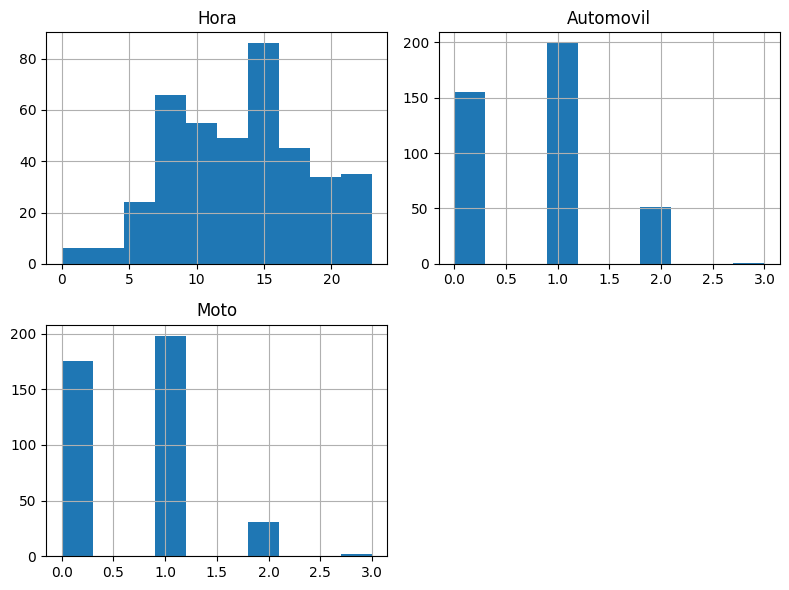

In [11]:
#histograma
data.hist(figsize=(8,6))
plt.tight_layout()

<Axes: >

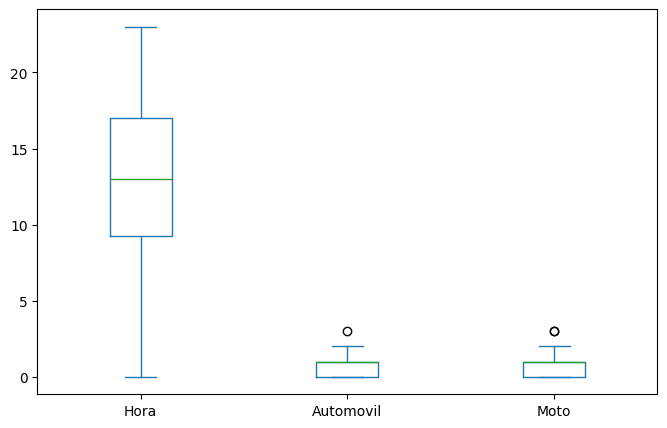

In [12]:
#Boxplot
data.plot.box(figsize=(8,5))

<Axes: >

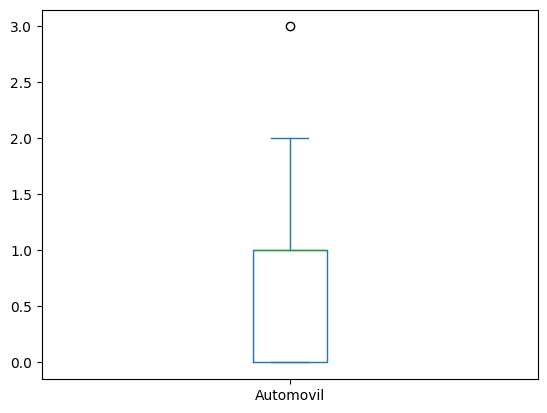

In [13]:
#Boxplot para una sola variable
data['Automovil'].plot.box()

<Axes: >

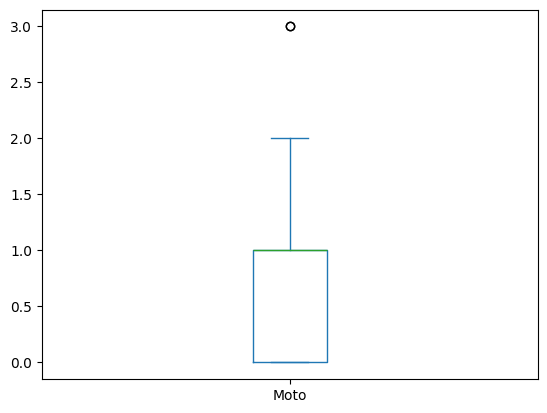

In [14]:
#Boxplot para una sola variable
data['Moto'].plot.box()

<Axes: >

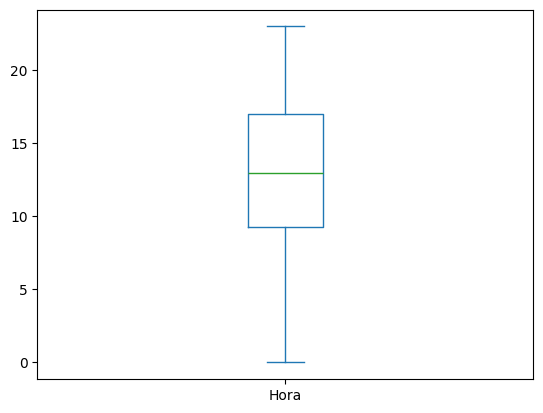

In [15]:
#Boxplot para una sola variable
data['Hora'].plot.box()


**Lectura de las variables numéricas.**
* `Hora`: va de 0 a 23, con media 13.3 y mediana 13; la mitad de los accidentes ocurre entre las 9:15 y las 17:00. No hay valores fuera de rango.
* `Automovil` y `Moto` son conteos pequeños: 155 accidentes sin automóviles, 199 con uno, 51 con dos y 1 con tres; y 175 sin motos, 198 con una, 31 con dos y 2 con tres. El boxplot marca como "atípicos" los de 2 y 3 vehículos, pero son casos posibles (se discute en la sección 4).


**Variables categóricas** (value_counts())

<Axes: xlabel='Gravedad'>

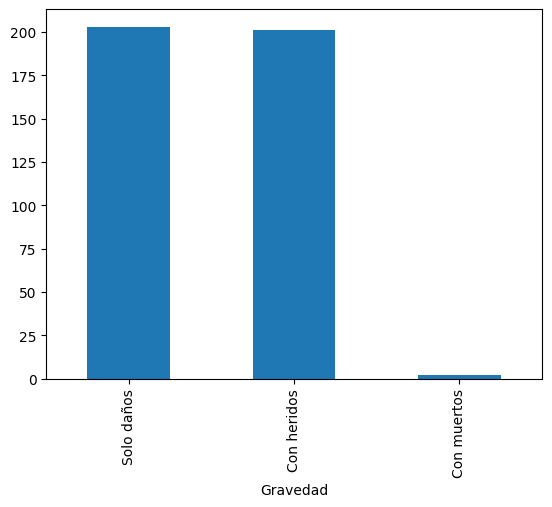

In [16]:
#Conocemos las variables categóricas: bar, barh, pie
data['Gravedad'].value_counts().plot(kind='bar')

<Axes: xlabel='Jornada'>

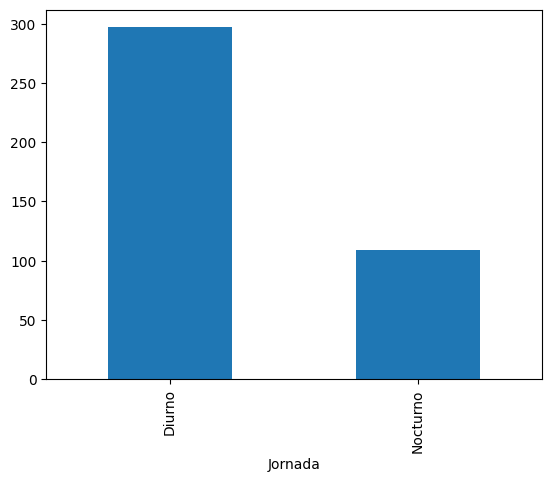

In [17]:
data['Jornada'].value_counts().plot(kind='bar')

<Axes: xlabel='Propietario'>

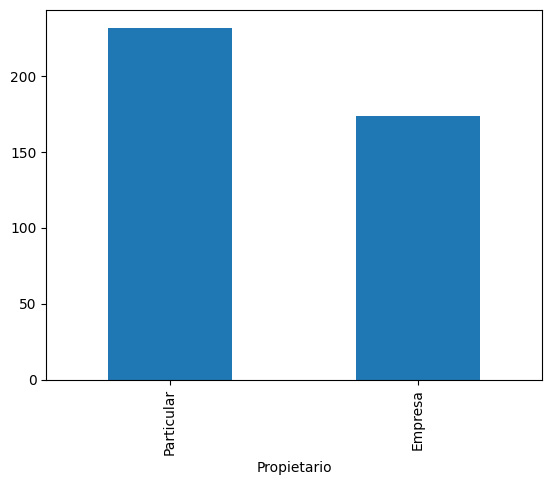

In [18]:
data['Propietario'].value_counts().plot(kind='bar')

<Axes: xlabel='Barrio'>

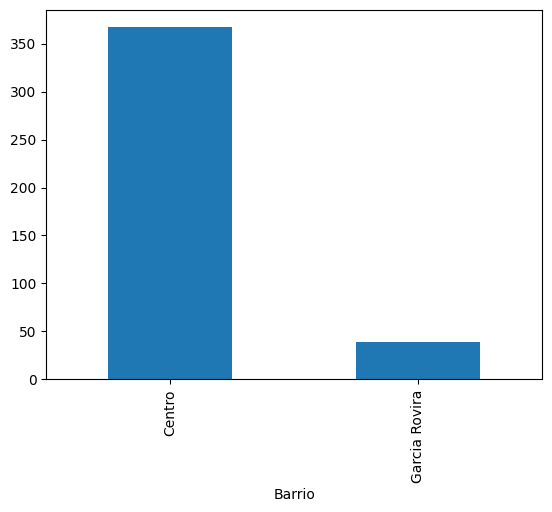

In [19]:
data['Barrio'].value_counts().plot(kind='bar')


**Lectura de las variables categóricas.**
* `Gravedad`: casi balanceada entre `Solo daños` (203) y `Con heridos` (201), con apenas 2 accidentes `Con muertos` (se trata en la sección 8).
* `Jornada`: 297 accidentes diurnos (73 %) y 109 nocturnos (27 %).
* `Propietario`: 232 vehículos particulares (57 %) y 174 de empresa (43 %).
* `Barrio`: 367 accidentes en el Centro (90 %) y solo 39 en García Rovira (10 %). Al estar casi todo en un barrio, esta variable tiene poco margen para diferenciar accidentes.


array([[<Axes: xlabel='Hora', ylabel='Hora'>,
        <Axes: xlabel='Automovil', ylabel='Hora'>,
        <Axes: xlabel='Moto', ylabel='Hora'>],
       [<Axes: xlabel='Hora', ylabel='Automovil'>,
        <Axes: xlabel='Automovil', ylabel='Automovil'>,
        <Axes: xlabel='Moto', ylabel='Automovil'>],
       [<Axes: xlabel='Hora', ylabel='Moto'>,
        <Axes: xlabel='Automovil', ylabel='Moto'>,
        <Axes: xlabel='Moto', ylabel='Moto'>]], dtype=object)

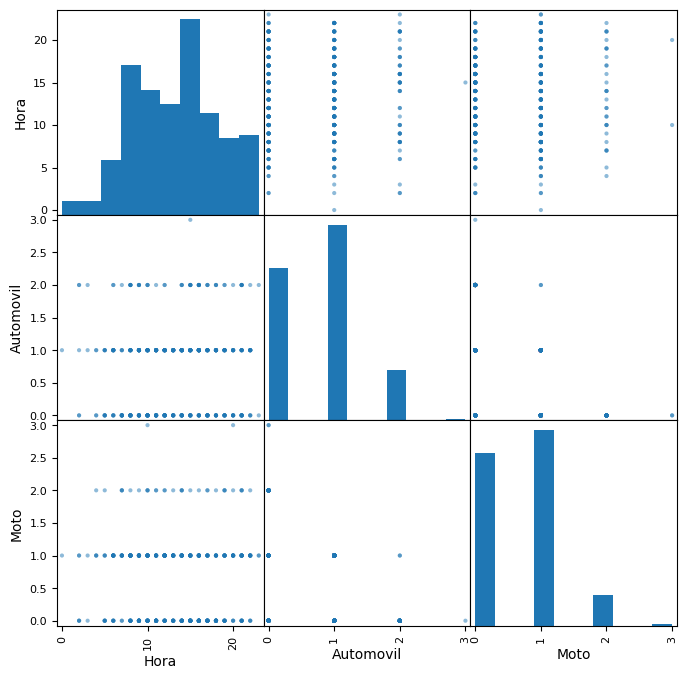

In [20]:
# Gráficas para identificar relaciones entre las variables numéricas
pd.plotting.scatter_matrix(data[['Hora','Automovil','Moto']], figsize=(8,8))


**Lectura de la matriz de dispersión.** Como `Automovil` y `Moto` toman pocos valores enteros, los puntos se ven como una cuadrícula con muchos puntos superpuestos, por lo que el gráfico dice poco; la correlación numérica de la sección 6 es más informativa (`Automovil` y `Moto` tienen correlación de -0.45; `Hora` no se relaciona con ninguna de las dos).


**Perfilado de datos**

In [21]:
!pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00


In [22]:
from ydata_profiling import ProfileReport

profile_data = ProfileReport(data, minimal=True) # minimal=True
profile_data

/tmp/ipykernel_1181/253920178.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 202.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Dimensiones de la Calidad de Datos**

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:** ¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados?

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?

# **Diagnóstico de las dimensiones según el perfilado:**
* **Completitud:** 100% completo, no existen valores nulos en ninguna de las 9 columnas (verificado en la sección 5).
* **Exactitud:** no se encontraron errores lógicos (horas fuera de 0-23, conteos de vehículos negativos, ni filas con cero vehículos/peatones involucrados). Ver detalle en la sección 4.
* **Conformidad:** las categorías de `Mes` y `Dia` vienen prefijadas con un número (ej. "01. Enero"), lo que garantiza un orden correcto pero no es el formato típico de texto; se documenta pero no se considera un error.
* **Oportunidad:** no se puede verificar con los metadatos disponibles del portal.
* **Duplicidad:** no se encontraron identificadores (`ORDEN`) repetidos.
* **Integridad:** el subconjunto queda limitado a una sola comuna y año (por diseño, para reducir el tamaño del archivo), por lo que no es representativo del municipio completo; esto se documenta como limitación del alcance, no como un problema de integridad interna de los datos.

# 4. Limpieza de datos atípicos-errores

**Diferencia clave:** un **error** es un valor imposible o incoherente (una hora 25, un conteo de vehículos negativo); un **atípico** es un valor extremo pero posible (un choque con 3 motos). Los errores se corrigen o se eliminan porque son datos mal registrados; los atípicos válidos se conservan, porque representan casos reales y eliminarlos haría perder información.

Por eso aquí **sólo se limpian errores** (valores lógicamente imposibles), no cualquier valor estadísticamente atípico. Las celdas siguientes revisan que `Hora` esté entre 0 y 23 y que `Automovil` y `Moto` no sean negativos.

In [24]:
data.describe()

,Hora,Automovil,Moto
count,406.000000,406.000000,406.000000
mean,13.256158,0.748768,0.655172
std,4.911905,0.674719,0.639684
min,0.000000,0.000000,0.000000
25%,9.250000,0.000000,0.000000
50%,13.000000,1.000000,1.000000
75%,17.000000,1.000000,1.000000
max,23.000000,3.000000,3.000000


In [25]:
# Revisión de errores lógicos:
# - Hora debe estar entre 0 y 23
# - Automovil y Moto (conteo de vehículos involucrados) no pueden ser negativos
print("Horas fuera de 0-23:", ((data['Hora']<0) | (data['Hora']>23)).sum())
print("Automovil negativos:", (data['Automovil']<0).sum())
print("Moto negativos:", (data['Moto']<0).sum())

Horas fuera de 0-23: 0
Automovil negativos: 0
Moto negativos: 0


No se encontraron errores lógicos en las variables numéricas (0 horas fuera de rango y 0 conteos negativos). Si bien el boxplot marca como "atípicos" (regla de rango intercuartílico) algunos accidentes con 3 automóviles o 3 motos involucrados, esos valores son perfectamente posibles en un accidente de tránsito real (choques múltiples), por lo que **no se eliminan ni se convierten a nulo**: no son errores, son casos extremos pero válidos.

**Resultado de la sección:** los 406 registros se conservan completos.

# 5. Limpieza de datos nulos: Imputación

Un **nulo** es un dato que falta. La mayoría de los modelos no puede trabajar con ellos, así que hay que eliminarlos o rellenarlos (imputar). La decisión depende de cuántos faltan.

Estrategia:
* Eliminar registros con más de 15% de nulos
* Eliminar columnas con más de 15%-20% de nulos
* Imputar por media, moda, mediana, vecinos cercanos. No se puede imputar más allá del 15% de los datos.
* Para casos especiales se crea modelo predictivo

Las celdas siguientes calculan el porcentaje de nulos de cada columna, en tabla y en gráfico.

In [26]:
# Porcentaje de nulos por columna
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

,0
Mes,0.0
Dia,0.0
Hora,0.0
Jornada,0.0
Barrio,0.0
Propietario,0.0
Automovil,0.0
Moto,0.0
Gravedad,0.0


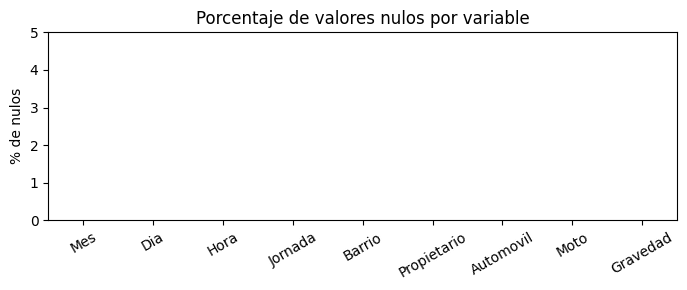

In [27]:
# Porcentaje de nulos de manera grafica
import matplotlib.pyplot as plt

nulos_pct = (data.isna().sum() / len(data) * 100)
nulos_pct.plot(kind='bar', color='#8172B2', figsize=(7,3))
plt.ylabel('% de nulos')
plt.title('Porcentaje de valores nulos por variable')
plt.ylim(0,5)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**No hay valores nulos en ninguna de las 9 columnas del dataset**, por lo tanto no es necesario aplicar ningún método de imputación en este caso: ninguna columna ni fila se acerca al umbral del 15 %, porque todas están completas. Se deja el código de referencia (`SimpleImputer`) documentado por si se llegaran a introducir nulos al combinar con datos de otras comunas o años.

In [28]:
from sklearn.impute import SimpleImputer

# Código de referencia (no se ejecuta imputación real porque no hay nulos):
# ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='mean')
# data[['Hora','Automovil','Moto']] = ImpNumeros.fit_transform(data[['Hora','Automovil','Moto']])
print("No hay nulos que imputar: 0 valores faltantes en", data.shape[0], "registros y", data.shape[1], "columnas.")

No hay nulos que imputar: 0 valores faltantes en 406 registros y 9 columnas.


# 6. Correlaciones para redundancias

Dos variables son **redundantes** si aportan casi la misma información (cuando una sube, la otra sube casi igual). Mantener las dos no mejora el modelo y puede distorsionar la importancia de ese factor. Para detectarlas se calcula la **correlación** entre todas las variables predictoras: un valor cercano a 1 o -1 indica relación lineal fuerte; cercano a 0, ninguna.

La correlación solo se puede calcular entre números, así que primero las variables categóricas se convierten en **dummies** (columnas 0/1, una por categoría; con `drop_first=True` se omite la primera categoría porque se deduce de las demás).

In [29]:
# Todas las variables deben ser numéricas para calcular las correlaciones
# Se crean dummies para las variables categóricas
data_num = pd.get_dummies(data, drop_first=True, dtype=int)
data_num.head()

,Hora,Automovil,Moto,Mes_02. Febrero,Mes_03. Marzo,Mes_04. Abril,Mes_05. Mayo,Mes_06. Junio,Mes_07. Julio,Mes_08. Agosto,...,Dia_03. Miercoles,Dia_04. Jueves,Dia_05. Viernes,Dia_06. Sabado,Dia_07. Domingo,Jornada_Nocturno,Barrio_Garcia Rovira,Propietario_Particular,Gravedad_Con muertos,Gravedad_Solo daños
19647,21,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,1,1,0,1
19661,12,1,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
19668,19,1,1,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,0,0
19670,14,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19678,13,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


**Correlaciones para redundancia = mayores |0.8|**

Se usa 0.8 como umbral: por encima de ese valor, dos variables se consideran prácticamente equivalentes. En el mapa de calor, los colores rojos fuertes indican correlación positiva alta y los azules fuertes correlación negativa alta; lo que interesa es que no aparezcan colores extremos fuera de la diagonal entre predictoras.

In [30]:
#Correlaciones
correlaciones = data_num.corr()
correlaciones

,Hora,Automovil,Moto,Mes_02. Febrero,Mes_03. Marzo,Mes_04. Abril,Mes_05. Mayo,Mes_06. Junio,Mes_07. Julio,Mes_08. Agosto,...,Dia_03. Miercoles,Dia_04. Jueves,Dia_05. Viernes,Dia_06. Sabado,Dia_07. Domingo,Jornada_Nocturno,Barrio_Garcia Rovira,Propietario_Particular,Gravedad_Con muertos,Gravedad_Solo daños
Hora,1.000000,0.048522,-8.942224e-04,0.023855,-0.070649,3.425492e-02,-0.007154,-0.041081,0.066710,-0.020023,...,-0.061084,-2.962180e-02,0.038810,0.073955,0.006502,0.422663,0.076688,-0.017682,-0.139923,-5.823948e-02
Automovil,0.048522,1.000000,-4.529296e-01,0.054792,0.003887,-2.432911e-02,-0.060717,0.036373,0.027663,0.054553,...,-0.011495,5.372841e-02,0.074927,-0.035666,-0.037973,0.019664,-0.176155,-0.116062,-0.025974,4.312893e-01
Moto,-0.000894,-0.452930,1.000000e+00,-0.042429,-0.008757,1.496926e-02,0.036132,-0.026524,-0.013814,-0.043420,...,-0.123553,4.818969e-02,-0.063610,0.079991,0.073008,0.048595,0.162860,0.124644,0.037975,-5.011728e-01
Mes_02. Febrero,0.023855,0.054792,-4.242871e-02,1.000000,-0.087005,-8.112739e-02,-0.096700,-0.089843,-0.085561,-0.092625,...,0.042336,4.204816e-02,0.068557,-0.035008,-0.070970,0.070313,-0.064333,-0.079163,-0.020581,1.828181e-02
Mes_03. Marzo,-0.070649,0.003887,-8.756554e-03,-0.087005,1.000000,-8.249562e-02,-0.098331,-0.091359,-0.087005,-0.094187,...,0.037738,3.785628e-02,0.037856,0.009398,-0.102373,-0.139515,-0.005198,-0.088466,-0.020928,9.914739e-02
Mes_04. Abril,0.034255,-0.024329,1.496926e-02,-0.081127,-0.082496,1.000000e+00,-0.091689,-0.085187,-0.081127,-0.087825,...,-0.046008,1.173947e-17,0.027735,-0.023645,0.059938,0.047786,0.006955,-0.011043,-0.019514,9.563796e-03
Mes_05. Mayo,-0.007154,-0.060717,3.613155e-02,-0.096700,-0.098331,-9.168911e-02,1.000000,-0.101540,-0.096700,-0.104683,...,-0.013381,-3.636488e-02,-0.036365,-0.039565,0.020507,-0.069728,0.032468,0.186094,0.212831,-3.305898e-02
Mes_06. Junio,-0.041081,0.036373,-2.652401e-02,-0.089843,-0.091359,-8.518741e-02,-0.101540,1.000000,-0.089843,-0.097260,...,0.005299,4.387822e-03,0.004388,-0.045521,-0.020159,-0.027655,0.048779,0.088666,-0.021611,-8.775645e-03
Mes_07. Julio,0.066710,0.027663,-1.381400e-02,-0.085561,-0.087005,-8.112739e-02,-0.096700,-0.089843,1.000000,-0.092625,...,0.017711,-9.049496e-02,-0.010969,-0.010670,-0.041265,0.049686,0.090770,0.105550,-0.020581,-3.656362e-02
Mes_08. Agosto,-0.020023,0.054553,-4.341961e-02,-0.092625,-0.094187,-8.782456e-02,-0.104683,-0.097260,-0.092625,1.000000,...,0.020614,-5.220544e-02,-0.027386,0.039006,-0.053362,-0.037339,-0.074182,-0.192704,-0.022280,8.558269e-03


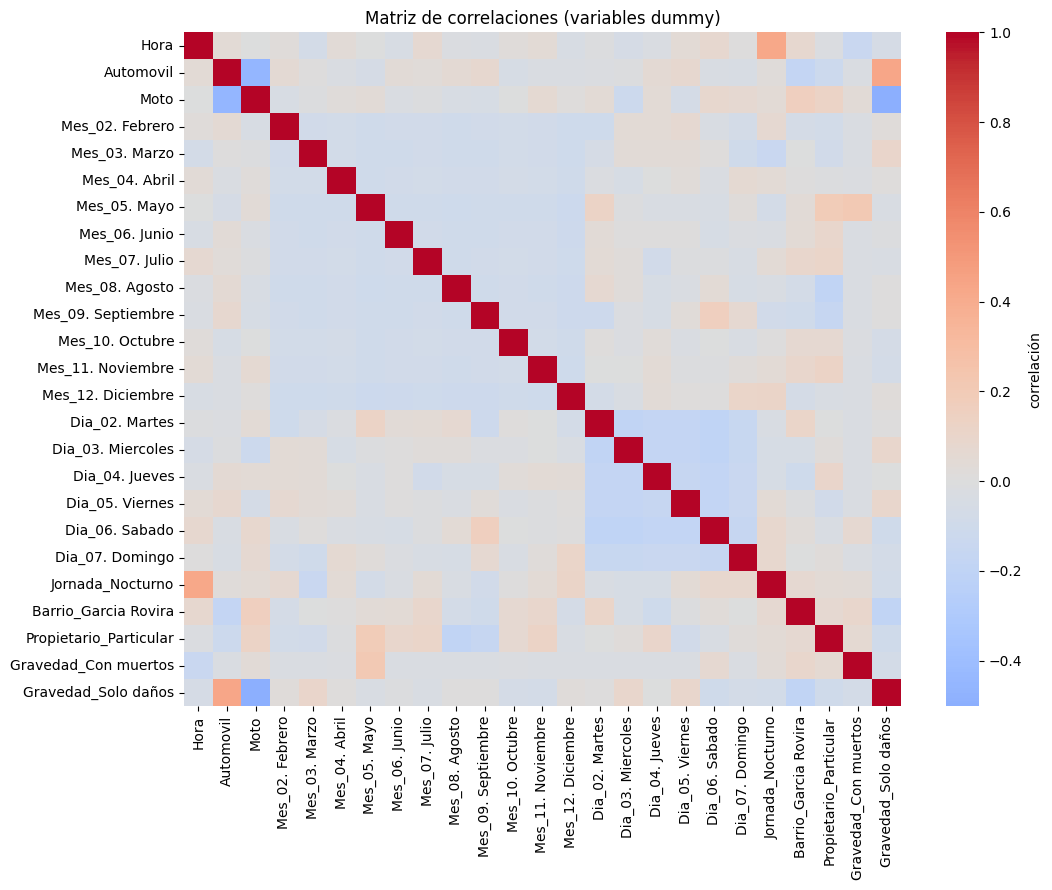

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(correlaciones, cmap='coolwarm', center=0, ax=ax, cbar_kws={'label':'correlación'})
plt.title('Matriz de correlaciones (variables dummy)')
plt.tight_layout()
plt.show()

In [32]:
# Búsqueda automática de pares de variables PREDICTORAS con correlación > 0.8 en valor absoluto
target_cols = [c for c in correlaciones.columns if c.startswith('Gravedad_')]
pred_cols = [c for c in correlaciones.columns if c not in target_cols]

pares_redundantes = []
for i, c1 in enumerate(pred_cols):
    for c2 in pred_cols[i+1:]:
        v = correlaciones.loc[c1, c2]
        if abs(v) > 0.8:
            pares_redundantes.append((c1, c2, round(v,3)))

print("Pares de variables predictoras con |correlación| > 0.8:", pares_redundantes)

Pares de variables predictoras con |correlación| > 0.8: []


No se encontraron pares de variables predictoras con correlación mayor a |0.8|, por lo tanto **no hay redundancia matemática** entre las variables predictoras de este dataset y no es necesario eliminar ninguna por este criterio.

Las correlaciones más altas entre predictoras son moderadas: `Automovil` con `Moto` (-0.45) y `Hora` con `Jornada_Nocturno` (0.42); en ambos casos tiene sentido (más autos deja menos espacio a motos en un mismo accidente; la jornada nocturna depende de la hora), pero no son tan altas como para considerarlas la misma información.

# 7. Correlaciones para irrelevancia con la variable objetivo

Se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05) -> la variable es candidata a eliminarse (la decisión final se toma en la sección 9, con más criterios).

Como `Gravedad` tiene 3 categorías, `get_dummies` genera dos columnas de referencia: `Gravedad_Con muertos` y `Gravedad_Solo daños` (la categoría "Con heridos" queda como referencia/base). Dado que la clase "Con muertos" solo tiene 2 registros en este subconjunto, sus correlaciones no son estadísticamente confiables (ruido), así que el análisis de relevancia se centra en `Gravedad_Solo daños`, que contrasta "accidentes sin víctimas" contra "accidentes con heridos o muertos".

**Cómo leer el signo:** `Gravedad_Solo daños` vale 1 cuando el accidente solo dejó daños materiales. Una correlación **negativa** con una variable significa que, al aumentar esa variable, los accidentes de solo daños son menos frecuentes (es decir, hay más accidentes con víctimas); una correlación **positiva**, lo contrario.

In [33]:
#Correlaciones con la variable objetivo (accidentes con víctimas vs. solo daños)
cor_variable_obj = correlaciones.loc['Gravedad_Solo daños'].drop(target_cols)
cor_variable_obj.sort_values(key=abs, ascending=False)

,Gravedad_Solo daños
Moto,-5.011728e-01
Automovil,4.312893e-01
Barrio_Garcia Rovira,-1.922483e-01
Propietario_Particular,-9.954315e-02
Mes_03. Marzo,9.914739e-02
Dia_06. Sabado,-9.836753e-02
Dia_03. Miercoles,8.625933e-02
Dia_05. Viernes,8.571429e-02
Jornada_Nocturno,-8.336808e-02
Mes_11. Noviembre,-7.312724e-02


Text(0.5, 1.0, 'Correlación de cada predictora con Gravedad_Solo daños')

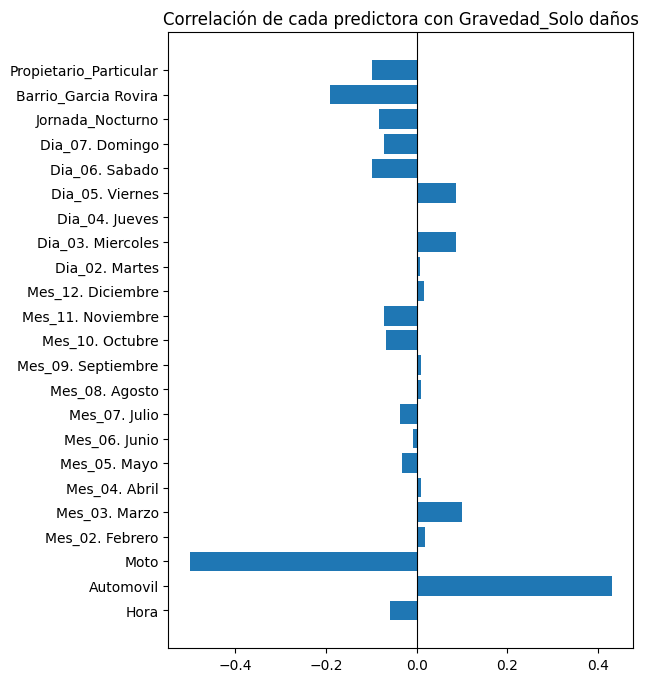

In [34]:
plt.figure(figsize=(6, 8))
plt.barh(y=cor_variable_obj.index, width=cor_variable_obj.values)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada predictora con Gravedad_Solo daños')

**Lectura de las correlaciones:** `Moto` (-0.50) y `Automovil` (0.43) son, con diferencia, las variables más correlacionadas con la gravedad; `Barrio_Garcia Rovira` (-0.19) le sigue. `Hora`, `Jornada`, `Propietario` y la mayoría de las dummies de mes y día muestran correlaciones bajas (< |0.10|).

Las correlaciones de las dummies de `Mes` y `Dia` son débiles por construcción (cada dummy describe un solo mes o un solo día), así que **no se elimina ninguna variable solo con este criterio**: la decisión de conservar o descartar cada variable se toma en la sección 9 con pruebas estadísticas de asociación, información mutua e importancia de Random Forest.

# 8. Variable objetivo y balanceo

**Cambio respecto a la versión anterior:** la clase `Con muertos` tiene solo **2 registros** en este subconjunto. Con tan pocos casos no es posible validar un modelo de forma confiable:

* En una validación cruzada de 10 particiones, esa clase no alcanza a aparecer en todos los pliegues.
* Sobre-muestrear con SMOTE a partir de 2 registros solo **replica casi idénticamente** esos 2 casos; al dividir en entrenamiento/prueba, las copias quedan en ambos lados y el modelo parece acertar (Recall de 0.98 en esa clase) cuando en realidad está reconociendo registros repetidos.

Por eso la variable objetivo se redefine como binaria:

* `Con víctimas` = `Con heridos` + `Con muertos`
* `Solo daños`

Con esta agrupación las dos clases quedan prácticamente iguales (203 vs 203 registros), por lo que **ya no se necesita SMOTE** y se evita fabricar datos.

Gravedad
Solo daños      203
Con víctimas    203
Name: count, dtype: int64

Gravedad
Solo daños      0.5
Con víctimas    0.5
Name: proportion, dtype: float64


<Axes: title={'center': 'Variable objetivo: Gravedad'}, xlabel='Gravedad'>

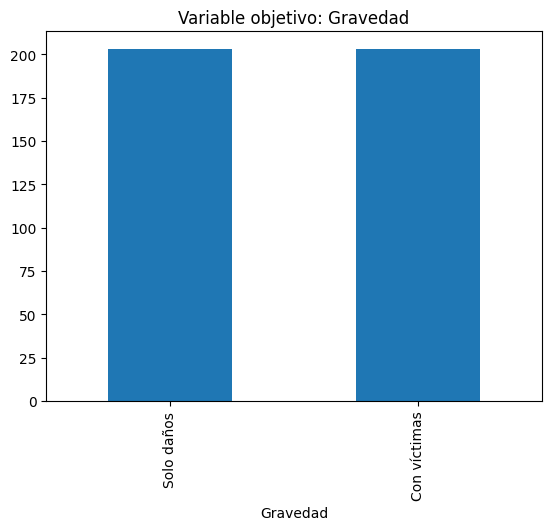

In [35]:
# Variable objetivo binaria: Con víctimas (heridos + muertos) vs Solo daños
data['Gravedad'] = data['Gravedad'].astype(str).map(
    lambda g: 'Solo daños' if g == 'Solo daños' else 'Con víctimas')

print(data['Gravedad'].value_counts())
print()
print(data['Gravedad'].value_counts(normalize=True).round(3))
data['Gravedad'].value_counts().plot(kind='bar', title='Variable objetivo: Gravedad')

Si la proporción de la clase minoritaria fuera menor al ~40%, se usaría `class_weight='balanced'` o SMOTE **dentro** de cada pliegue de la validación cruzada (nunca antes de dividir), para no contaminar la evaluación.

# 9. Selección de factores

**Objetivo:** identificar qué variables son realmente relevantes para explicar la gravedad del accidente, para quedarnos solo con los factores que aportan información al modelo.

Se combinan tres criterios sobre las 8 variables candidatas (`Mes`, `Dia`, `Hora`, `Jornada`, `Barrio`, `Propietario`, `Automovil`, `Moto`):

1. **Prueba estadística de asociación con la gravedad:** Chi-cuadrado para variables categóricas y Mann-Whitney U para variables numéricas. Criterio de selección: **p-valor < 0.05**.
2. **Información mutua:** cuánta información comparte cada variable con la gravedad (evidencia de apoyo, captura relaciones no lineales).
3. **Importancia en un Random Forest:** importancia de las dummies sumada por variable original (evidencia de apoyo).

Las redundancias entre predictoras ya se descartaron en la sección 6 (ningún par con |correlación| > 0.8).

**Cómo leer la tabla de resultados:**
* **p-valor:** probabilidad de observar una asociación así de fuerte si la variable en realidad no tuviera relación con la gravedad. Por debajo de 0.05 se considera que la relación es estadísticamente significativa.
* **Info. mutua:** cuánta información sobre la gravedad entrega la variable. Vale 0 si son independientes y crece cuanto más se relacionan.
* **Importancia RF:** porcentaje de la "decisión" del Random Forest que se apoya en esa variable (las 8 suman 1).
* Se usan tres criterios porque cada uno mira algo distinto: el primero responde si la relación es real o por azar, y los otros dos cuánto pesa la variable.

In [36]:
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

objetivo = 'Gravedad'
numericas = ['Hora', 'Automovil', 'Moto']
predictoras = [c for c in data.columns if c != objetivo]
categoricas = [c for c in predictoras if c not in numericas]
y_bin = (data[objetivo] == 'Con víctimas').astype(int)

# --- Criterio 1: prueba de asociación con la variable objetivo
filas = []
for c in predictoras:
    if c in numericas:
        p = mannwhitneyu(data.loc[y_bin == 1, c], data.loc[y_bin == 0, c], alternative='two-sided').pvalue
        prueba = 'Mann-Whitney U'
    else:
        p = chi2_contingency(pd.crosstab(data[c].astype(str), y_bin))[1]
        prueba = 'Chi-cuadrado'
    filas.append({'Variable': c, 'Prueba': prueba, 'p-valor': p})
seleccion = pd.DataFrame(filas).set_index('Variable')

# --- Criterio 2: información mutua (variables codificadas como enteros)
X_cod = data[predictoras].copy()
for c in categoricas:
    X_cod[c] = X_cod[c].astype(str).astype('category').cat.codes
seleccion['Info. mutua'] = mutual_info_classif(X_cod, y_bin, discrete_features=True, random_state=42)

# --- Criterio 3: importancia Random Forest (dummies sumadas por variable original)
X_dum = pd.get_dummies(data[predictoras].astype({c: str for c in categoricas}), columns=categoricas, dtype=int)
rf_sel = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42).fit(X_dum, y_bin)
imp = pd.Series(rf_sel.feature_importances_, index=X_dum.columns)
origen = lambda col: next(v for v in predictoras if col == v or col.startswith(v + '_'))
seleccion['Importancia RF'] = imp.groupby(origen).sum()

seleccion['Seleccionada'] = seleccion['p-valor'] < 0.05
seleccion = seleccion.sort_values('p-valor')
seleccion.round(4)

,Prueba,p-valor,Info. mutua,Importancia RF,Seleccionada
Variable,,,,,
Moto,Mann-Whitney U,0.0000,0.1515,0.3706,True
Automovil,Mann-Whitney U,0.0000,0.1035,0.2166,True
Barrio,Chi-cuadrado,0.0002,0.0196,0.0497,True
Propietario,Chi-cuadrado,0.0567,0.0050,0.0361,False
Dia,Chi-cuadrado,0.1113,0.0128,0.0902,False
Jornada,Chi-cuadrado,0.1169,0.0035,0.0222,False
Hora,Mann-Whitney U,0.2639,0.0428,0.1145,False
Mes,Chi-cuadrado,0.5329,0.0124,0.1001,False


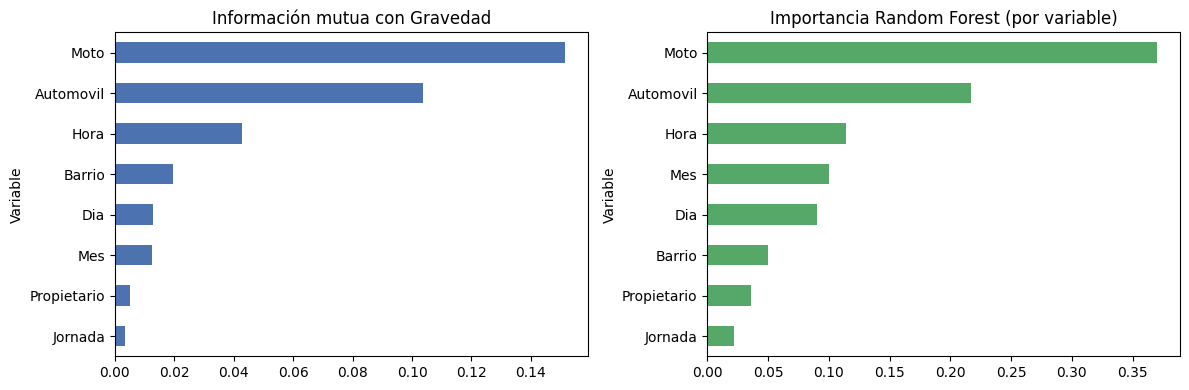

In [37]:
# Evidencia gráfica: información mutua e importancia RF por variable
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
seleccion['Info. mutua'].sort_values().plot.barh(ax=ax[0], color='#4C72B0', title='Información mutua con Gravedad')
seleccion['Importancia RF'].sort_values().plot.barh(ax=ax[1], color='#55A868', title='Importancia Random Forest (por variable)')
plt.tight_layout()
plt.show()

In [38]:
variables_seleccionadas = seleccion.index[seleccion['Seleccionada']].tolist()

# Respaldo: si el criterio estadístico deja menos de 3 variables, se toman las 3 con mayor información mutua
if len(variables_seleccionadas) < 3:
    variables_seleccionadas = seleccion['Info. mutua'].nlargest(3).index.tolist()

descartadas = [c for c in predictoras if c not in variables_seleccionadas]
print("Variables seleccionadas:", variables_seleccionadas)
print("Variables descartadas:  ", descartadas)

Variables seleccionadas: ['Moto', 'Automovil', 'Barrio']
Variables descartadas:   ['Mes', 'Dia', 'Hora', 'Jornada', 'Propietario']


**Conclusión de la selección de factores:** de las 8 variables candidatas se conservaron 3: `Moto`, `Automovil` y `Barrio` (Centro / García Rovira). Son las únicas con asociación estadísticamente significativa con la gravedad (p < 0.05): `Moto` y `Automovil` con p < 0.001 y `Barrio` con p = 0.0002. `Moto` es además la más informativa según los otros dos criterios (información mutua 0.152 e importancia en Random Forest 0.371), seguida de `Automovil` (0.104 y 0.217).

El sentido de la relación se ve en las correlaciones de la sección 7: a más motos involucradas, más accidentes con víctimas (-0.50 con "Solo daños"), y a más automóviles, más accidentes con solo daños materiales (+0.43).

Se descartaron `Mes`, `Dia`, `Hora`, `Jornada` y `Propietario`. `Hora` y `Mes` no muestran relación con la gravedad (p = 0.26 y 0.53). `Propietario` (p = 0.057) quedó cerca del umbral sin alcanzarlo, y `Dia` (p = 0.11) y `Jornada` (p = 0.12) están más lejos: si aportan algo, es muy poco y con 406 registros no se distingue del azar.

*Limitación:* la selección se hizo con todos los registros; en rigor, lo ideal sería repetirla dentro de cada pliegue. Con solo 8 candidatas y criterios estadísticos simples, el sesgo es pequeño, pero conviene mencionarlo.

# 10. Transformaciones

Solo se transforman las variables seleccionadas:

* **Dummies** para las categóricas (`drop_first=True`). Es una transformación determinística (no aprende nada de los datos), por lo que no hay fuga de información.
* **LabelEncoder** para la variable objetivo.
* **Normalización (MinMax)** de las variables numéricas: **no se hace aquí**. Se incluye dentro del *Pipeline* de cada modelo que la necesita (KNN, Red Neuronal, SVM), de modo que en la validación cruzada el escalador se ajusta solo con los datos de entrenamiento de cada pliegue. Si se normalizara todo el dataset antes, los datos de prueba influirían en el escalado (fuga de información).

**Resultado esperado:** las variables numéricas (`Moto`, `Automovil`) quedan tal cual; `Barrio` tiene solo dos categorías, por lo que genera una única columna dummy (`Barrio_Garcia Rovira`); y la variable objetivo pasa a números con el LabelEncoder (`Con víctimas` = 0, `Solo daños` = 1). En total quedan 3 variables predictoras numéricas para los modelos.

In [39]:
from sklearn.preprocessing import LabelEncoder

data_modelo = data[variables_seleccionadas + [objetivo]].copy()
num_sel = [c for c in variables_seleccionadas if c in numericas]
cat_sel = [c for c in variables_seleccionadas if c in categoricas]

# Dummies
for c in cat_sel:
    data_modelo[c] = data_modelo[c].astype(str)
data_modelo = pd.get_dummies(data_modelo, columns=cat_sel, drop_first=True, dtype=int)

# LabelEncoder (solo variable objetivo)
labelencoder = LabelEncoder()
data_modelo[objetivo] = labelencoder.fit_transform(data_modelo[objetivo].astype(str))
print(dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_))))

X = data_modelo.drop(objetivo, axis=1)   # Variables predictoras
Y = data_modelo[objetivo]                # Variable objetivo
print("Registros:", X.shape[0], "| Variables predictoras (tras dummies):", X.shape[1])
X.head()

{'Con víctimas': np.int64(0), 'Solo daños': np.int64(1)}
Registros: 406 | Variables predictoras (tras dummies): 3


,Moto,Automovil,Barrio_Garcia Rovira
19647,0,1,1
19661,1,1,0
19668,1,1,1
19670,1,0,0
19678,1,0,0


In [40]:
# Información que necesita el despliegue para construir la interfaz y preparar los datos nuevos
info_despliegue = {
    'objetivo': objetivo,
    'clases': labelencoder.classes_.tolist(),
    'columnas_entrada': variables_seleccionadas,
    'numericas': {c: [int(data[c].min()), int(data[c].max())] for c in num_sel},
    'categoricas': {c: sorted(data[c].astype(str).unique().tolist()) for c in cat_sel},
    'variables': X.columns.tolist(),
}
info_despliegue

{'objetivo': 'Gravedad',
 'clases': ['Con víctimas', 'Solo daños'],
 'columnas_entrada': ['Moto', 'Automovil', 'Barrio'],
 'numericas': {'Moto': [0, 3], 'Automovil': [0, 3]},
 'categoricas': {'Barrio': ['Centro', 'Garcia Rovira']},
 'variables': ['Moto', 'Automovil', 'Barrio_Garcia Rovira']}

# 11. Modelo predictivo con validación cruzada

**Objetivo del modelo:** predecir si un accidente de tránsito en la Comuna Centro de Bucaramanga termina **con víctimas** (heridos o muertos) o **solo con daños materiales**, a partir de los factores seleccionados, para entender qué condiciones se asocian con accidentes más graves y apoyar la priorización de acciones de prevención.

**Estrategia de evaluación**

* **Validación cruzada estratificada de 10 pliegues** (`StratifiedKFold`, `shuffle=True`, `random_state=42`): cada pliegue conserva la proporción de clases y todos los registros se usan para entrenar y para evaluar.
* **Medida principal:** F1 macro (promedia el F1 de ambas clases). También se reportan Accuracy, Precision, Recall (macro) y AUC.
* **Overfitting / underfitting:** `return_train_score=True` permite comparar el desempeño en entrenamiento contra el de prueba. Criterio de referencia: **diferencia train − test > 0.05 (5 puntos) ⇒ overfitting**; un desempeño bajo incluso en train (F1 < 0.70) sugiere **underfitting** o que las variables no alcanzan a explicar el fenómeno. Son umbrales de referencia, no reglas absolutas.
* Los modelos que son sensibles a la escala (KNN, Red Neuronal, SVM) incluyen un `MinMaxScaler` dentro de su *Pipeline*.

**Métricas que se calculan en cada pliegue** (la variable objetivo es binaria y las clases están balanceadas):
* **Accuracy (exactitud):** porcentaje de accidentes clasificados correctamente.
* **Precision macro:** de los accidentes que el modelo marca como una clase, cuántos realmente lo son; se calcula para cada clase y se promedia.
* **Recall macro:** de los accidentes que realmente son de una clase, cuántos detecta el modelo; también se promedia entre las dos clases.
* **F1 macro:** combina precision y recall en un solo número (media armónica) y se promedia entre las dos clases. Es la medida principal porque penaliza que el modelo falle en cualquiera de las dos.
* **AUC (ROC):** qué tan bien ordena el modelo los accidentes, de menos a más probables de tener víctimas, sin depender de un umbral. 0.5 equivale a adivinar y 1.0 es separación perfecta.

**Cómo leer la tabla de cada modelo:** la columna *Train* es el desempeño en los datos con los que el modelo se entrenó en cada pliegue; *Test*, en los datos que no vio; y *Diferencia* es Train − Test. Una diferencia grande indica que el modelo memoriza el entrenamiento (overfitting).

In [41]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)   # Muestreo estratificado
metricas = ['f1_macro', 'accuracy', 'precision_macro', 'recall_macro', 'roc_auc']
ESCALAR = ['KNN', 'Red Neuronal', 'SVM']    # modelos que requieren normalización

def construir(nombre):
    """Devuelve el Pipeline (escalado opcional + modelo) con la configuración base de cada técnica."""
    modelos = {
        'Árbol': DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=5,
                                        class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=50, max_samples=0.9, criterion='gini',
                                                max_depth=7, min_samples_leaf=2,
                                                class_weight='balanced', random_state=42),
        'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.05,
                                 eval_metric='logloss', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
        'Red Neuronal': MLPClassifier(activation='relu', hidden_layer_sizes=(16,), max_iter=1000, random_state=3),
        'SVM': SVC(kernel='poly', degree=2, C=1, gamma='scale', class_weight='balanced',
                   probability=True, random_state=42),
    }
    pasos = []
    if nombre in ESCALAR and num_sel:
        pasos.append(('escala', ColumnTransformer([('num', MinMaxScaler(), num_sel)], remainder='passthrough')))
    pasos.append(('clf', modelos[nombre]))
    return Pipeline(pasos)

def diagnostico(train, test):
    if train - test > 0.05:
        return 'Overfitting'
    if train < 0.70:
        return 'Desempeño bajo (posible underfitting)'
    return 'Ajuste adecuado'

resultados = {}   # puntajes de cada pliegue, por modelo

def evaluar_cv(nombre):
    """Validación cruzada de 10 pliegues; muestra promedios train vs test y la diferencia (overfitting)."""
    s = pd.DataFrame(cross_validate(construir(nombre), X, Y, cv=cv, scoring=metricas,
                                    return_train_score=True, n_jobs=-1))
    resultados[nombre] = s
    med = s.mean()
    tabla = pd.DataFrame({'Train': [med['train_' + m] for m in metricas],
                          'Test':  [med['test_' + m] for m in metricas]}, index=metricas)
    tabla['Diferencia'] = tabla['Train'] - tabla['Test']
    display(tabla.round(3))
    print("Diagnóstico (F1 macro):", diagnostico(tabla.loc['f1_macro', 'Train'], tabla.loc['f1_macro', 'Test']))

## Árbol de decisión
*Técnica:* divide los datos con reglas `si variable ≤ umbral`; es interpretable y no requiere normalización.
*Configuración:* criterio `gini`, `max_depth=3` y `min_samples_leaf=5` (limitan la complejidad para evitar memorizar), `class_weight='balanced'`.

In [42]:
evaluar_cv('Árbol')

,Train,Test,Diferencia
f1_macro,0.749,0.739,0.010
accuracy,0.750,0.741,0.009
precision_macro,0.757,0.752,0.004
recall_macro,0.750,0.741,0.010
roc_auc,0.826,0.809,0.018


Diagnóstico (F1 macro): Ajuste adecuado


**Resultado:** el Árbol de decisión logra un F1 macro de 0.739 en test (0.749 en train) y un AUC de 0.809. La diferencia train − test es de apenas 0.010, así que no sobreajusta: la profundidad limitada a 3 niveles cumple su función.

## Random Forest
*Técnica:* conjunto de árboles entrenados con submuestras (bagging); promedia sus votos y reduce la varianza de un árbol individual. No requiere normalización.
*Configuración:* `n_estimators=50`, `max_samples=0.9`, `max_depth=7`, `min_samples_leaf=2`, `class_weight='balanced'`.

In [43]:
evaluar_cv('Random Forest')

,Train,Test,Diferencia
f1_macro,0.755,0.746,0.008
accuracy,0.756,0.749,0.008
precision_macro,0.763,0.759,0.004
recall_macro,0.756,0.748,0.008
roc_auc,0.833,0.822,0.011


Diagnóstico (F1 macro): Ajuste adecuado


**Resultado:** el Random Forest obtiene un F1 macro de 0.746 en test (0.755 en train) y un AUC de 0.822. La diferencia de 0.008 indica un buen ajuste: promediar varios árboles le da estabilidad.

## XGBoost
*Técnica:* boosting de árboles pequeños: cada árbol corrige los errores del anterior. No requiere normalización.
*Configuración:* `n_estimators=50`, `max_depth=3`, `learning_rate=0.05` (aprendizaje lento y árboles poco profundos para controlar el sobreajuste).

In [44]:
evaluar_cv('XGBoost')

,Train,Test,Diferencia
f1_macro,0.753,0.739,0.014
accuracy,0.755,0.741,0.013
precision_macro,0.761,0.752,0.009
recall_macro,0.755,0.741,0.014
roc_auc,0.831,0.820,0.011


Diagnóstico (F1 macro): Ajuste adecuado


**Resultado:** XGBoost alcanza un F1 macro de 0.739 en test (0.753 en train) y un AUC de 0.820. Tiene la mayor diferencia train − test entre los modelos (0.014), aunque sigue muy por debajo del umbral de 0.05.

## KNN
*Técnica:* clasifica según la clase mayoritaria de los *k* registros más cercanos. Depende de distancias, por eso las variables numéricas se normalizan (MinMax) dentro del Pipeline.
*Configuración:* `n_neighbors=5`, métrica `euclidean`.

In [45]:
evaluar_cv('KNN')

,Train,Test,Diferencia
f1_macro,0.725,0.713,0.011
accuracy,0.734,0.724,0.010
precision_macro,0.767,0.760,0.007
recall_macro,0.734,0.724,0.010
roc_auc,0.773,0.741,0.032


Diagnóstico (F1 macro): Ajuste adecuado


**Resultado:** KNN es el de menor desempeño: F1 macro de 0.713 en test (0.725 en train) y AUC de 0.741. Con solo tres variables de pocos valores posibles, muchos accidentes son idénticos entre sí y los vecinos no ayudan a distinguirlos; probablemente por eso rinde menos que los demás.

## Red Neuronal
*Técnica:* perceptrón multicapa; aprende combinaciones no lineales de las variables. Requiere normalización.
*Configuración:* una capa oculta de 16 neuronas, activación `relu`, optimizador `adam` (por defecto), `max_iter=1000`.

In [46]:
evaluar_cv('Red Neuronal')

,Train,Test,Diferencia
f1_macro,0.755,0.751,0.004
accuracy,0.756,0.754,0.003
precision_macro,0.762,0.764,-0.002
recall_macro,0.756,0.753,0.003
roc_auc,0.830,0.825,0.006


Diagnóstico (F1 macro): Ajuste adecuado


**Resultado:** la Red Neuronal obtiene el mayor F1 macro en test (0.751) y el mayor AUC (0.825), con una diferencia train − test de solo 0.004: casi no hay sobreajuste.

## SVM
*Técnica:* busca la frontera que separa las clases con el mayor margen; con un kernel polinomial puede capturar fronteras curvas. Requiere normalización.
*Configuración:* `kernel='poly'`, `degree=2`, `C=1`, `class_weight='balanced'`.

In [47]:
evaluar_cv('SVM')

,Train,Test,Diferencia
f1_macro,0.749,0.739,0.010
accuracy,0.750,0.741,0.009
precision_macro,0.756,0.752,0.004
recall_macro,0.750,0.741,0.010
roc_auc,0.769,0.746,0.023


Diagnóstico (F1 macro): Ajuste adecuado


**Resultado:** el SVM logra un F1 macro de 0.739 en test (0.749 en train), igual que el Árbol y XGBoost, pero con un AUC menor (0.746): clasifica bien, aunque ordena menos fino los accidentes por probabilidad.

# 12. Comparación de modelos y conclusiones

Criterio para elegir el mejor modelo: mayor **F1 macro en test**, **descartando los que presentan overfitting** (diferencia train − test > 0.05). Si hay empate técnico (diferencias menores a la desviación entre pliegues), se prefiere el modelo más simple.

**Qué se hace en esta sección:** (1) una tabla resumen con los promedios de los 10 pliegues; (2) gráficos de la variación del F1 entre pliegues y de train contra test; (3) una comparación detallada con matrices de confusión, curvas ROC y métricas por clase; (4) la selección del mejor modelo con el criterio anterior; y (5) las conclusiones.

In [48]:
# Tabla resumen: promedios de los 10 pliegues
resumen = pd.DataFrame({
    'F1 train':      {n: r['train_f1_macro'].mean() for n, r in resultados.items()},
    'F1 test':       {n: r['test_f1_macro'].mean() for n, r in resultados.items()},
    'Desv. F1 test': {n: r['test_f1_macro'].std() for n, r in resultados.items()},
    'Accuracy test': {n: r['test_accuracy'].mean() for n, r in resultados.items()},
    'Precision test':{n: r['test_precision_macro'].mean() for n, r in resultados.items()},
    'Recall test':   {n: r['test_recall_macro'].mean() for n, r in resultados.items()},
    'AUC test':      {n: r['test_roc_auc'].mean() for n, r in resultados.items()},
})
resumen['Diferencia'] = resumen['F1 train'] - resumen['F1 test']
resumen['Diagnóstico'] = [diagnostico(a, b) for a, b in zip(resumen['F1 train'], resumen['F1 test'])]
resumen.sort_values('F1 test', ascending=False).round(3)

,F1 train,F1 test,Desv. F1 test,Accuracy test,Precision test,Recall test,AUC test,Diferencia,Diagnóstico
Red Neuronal,0.755,0.751,0.062,0.754,0.764,0.753,0.825,0.004,Ajuste adecuado
Random Forest,0.755,0.746,0.073,0.749,0.759,0.748,0.822,0.008,Ajuste adecuado
SVM,0.749,0.739,0.065,0.741,0.752,0.741,0.746,0.010,Ajuste adecuado
XGBoost,0.753,0.739,0.072,0.741,0.752,0.741,0.820,0.014,Ajuste adecuado
Árbol,0.749,0.739,0.067,0.741,0.752,0.741,0.809,0.010,Ajuste adecuado
KNN,0.725,0.713,0.067,0.724,0.760,0.724,0.741,0.011,Ajuste adecuado


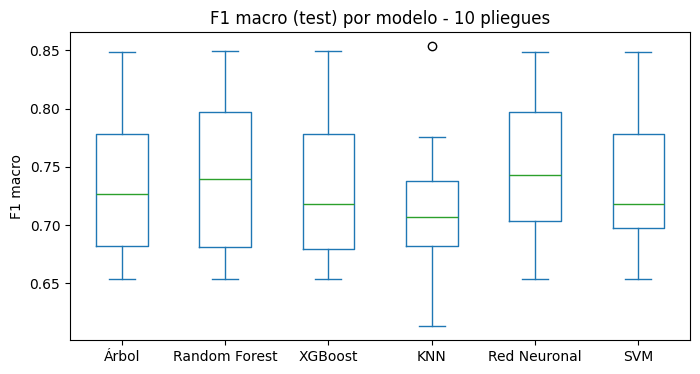

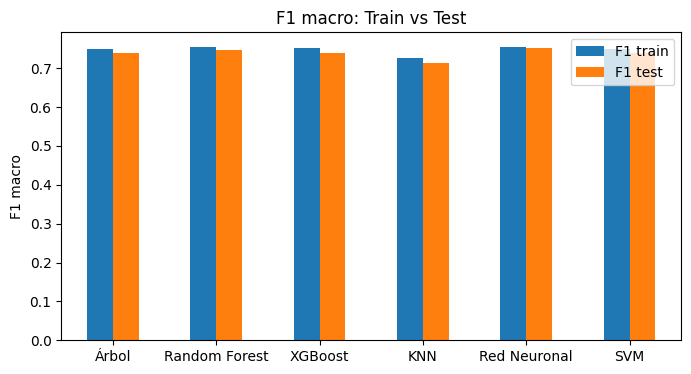

In [49]:
# Distribución del F1 macro de test en los 10 pliegues
comparacion_CV = pd.DataFrame({n: r['test_f1_macro'] for n, r in resultados.items()})
comparacion_CV.plot(kind='box', figsize=(8, 4), title='F1 macro (test) por modelo - 10 pliegues')
plt.ylabel('F1 macro')
plt.show()

# Train vs Test: revisión gráfica de overfitting
resumen[['F1 train', 'F1 test']].plot(kind='bar', figsize=(8, 4), title='F1 macro: Train vs Test')
plt.ylabel('F1 macro')
plt.xticks(rotation=0)
plt.show()


### Comparación detallada de los 6 modelos

La tabla y los gráficos anteriores resumen cada modelo con promedios. Para ver **cómo se equivoca** cada uno se usan predicciones *fuera de pliegue* (`cross_val_predict`): cada uno de los 406 accidentes se predice con un modelo entrenado sin ese accidente (validación cruzada de 10 pliegues). Con esas predicciones se construyen:

* **Matrices de confusión:** cuántos accidentes de cada clase acierta o confunde cada modelo (filas = clase real, columnas = clase predicha).
* **Curvas ROC:** qué tan bien separa cada modelo las dos clases a todos los umbrales posibles; cuanto más se acerca la curva a la esquina superior izquierda, mejor. El AUC resume la curva en un número.
* **Tabla por clase:** exactitud, precisión y recall de la clase `Con víctimas`, recall de `Solo daños`, F1 macro y AUC de los seis modelos.


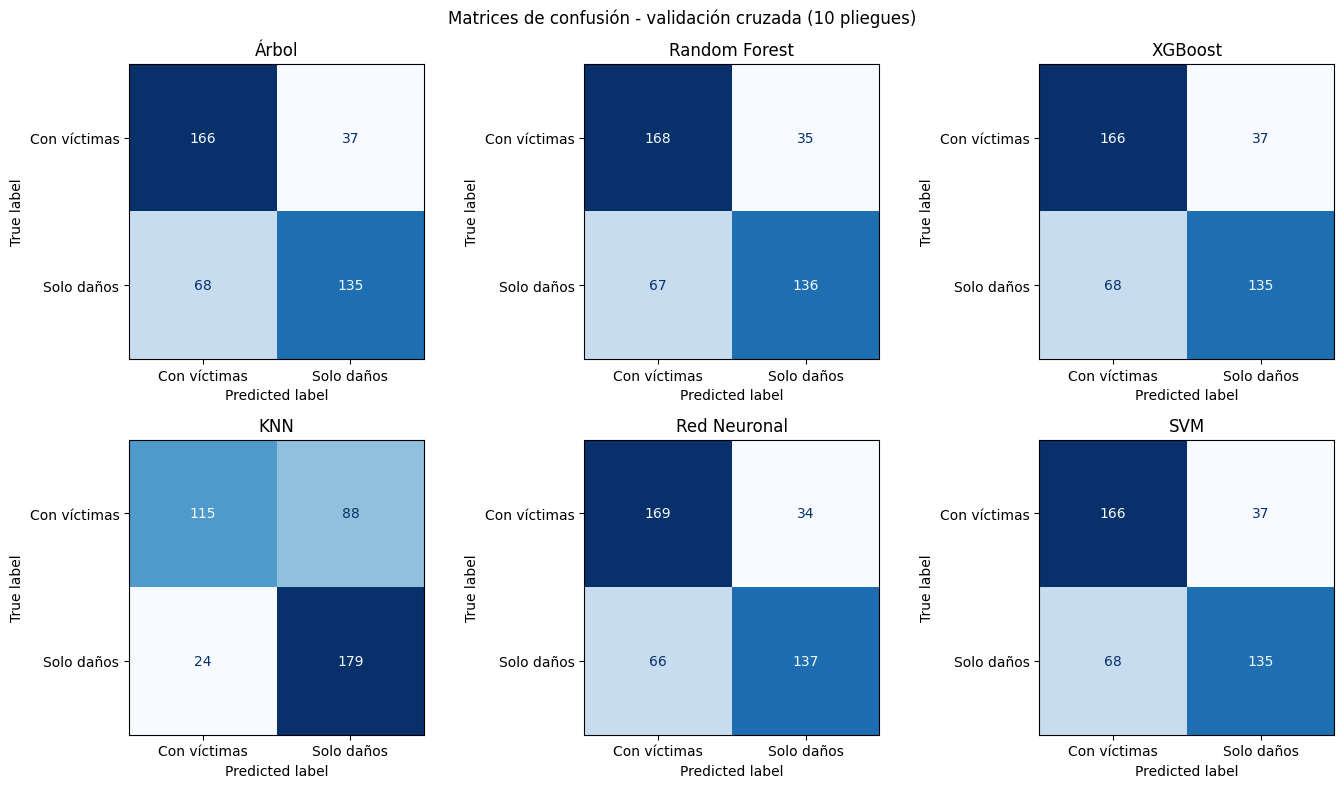

In [50]:

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

nombres = ['Árbol', 'Random Forest', 'XGBoost', 'KNN', 'Red Neuronal', 'SVM']
pred_oof, proba_oof = {}, {}
for n in nombres:
    pred_oof[n] = cross_val_predict(construir(n), X, Y, cv=cv, n_jobs=-1)
    # probabilidad de 'Con víctimas' (clase 0 del LabelEncoder)
    proba_oof[n] = cross_val_predict(construir(n), X, Y, cv=cv, method='predict_proba', n_jobs=-1)[:, 0]

# Matrices de confusión de los 6 modelos (predicciones fuera de pliegue)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, n in zip(axes.ravel(), nombres):
    ConfusionMatrixDisplay.from_predictions(Y, pred_oof[n], display_labels=labelencoder.classes_,
                                            cmap='Blues', colorbar=False, ax=ax)
    ax.set_title(n)
plt.suptitle('Matrices de confusión - validación cruzada (10 pliegues)')
plt.tight_layout()
plt.show()


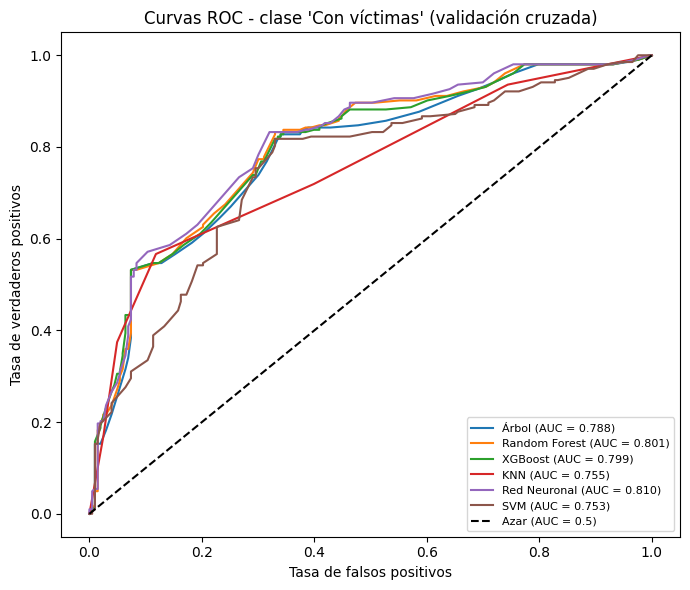

In [51]:

from sklearn.metrics import roc_curve, auc

y_vict = (Y == 0).astype(int)   # 1 = Con víctimas
auc_oof = {}
plt.figure(figsize=(7, 6))
for n in nombres:
    fpr, tpr, _ = roc_curve(y_vict, proba_oof[n])
    auc_oof[n] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{n} (AUC = {auc_oof[n]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title("Curvas ROC - clase 'Con víctimas' (validación cruzada)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [52]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

filas = []
for n in nombres:
    p = pred_oof[n]
    filas.append({'Modelo': n,
                  'Exactitud': accuracy_score(Y, p),
                  'Precisión (Con víctimas)': precision_score(Y, p, pos_label=0),
                  'Recall (Con víctimas)': recall_score(Y, p, pos_label=0),
                  'Recall (Solo daños)': recall_score(Y, p, pos_label=1),
                  'F1 macro': f1_score(Y, p, average='macro'),
                  'AUC': auc_oof[n]})
comparacion_final = pd.DataFrame(filas).set_index('Modelo').sort_values('F1 macro', ascending=False)
comparacion_final.round(3)


,Exactitud,Precisión (Con víctimas),Recall (Con víctimas),Recall (Solo daños),F1 macro,AUC
Modelo,,,,,,
Red Neuronal,0.754,0.719,0.833,0.675,0.752,0.810
Random Forest,0.749,0.715,0.828,0.670,0.747,0.801
Árbol,0.741,0.709,0.818,0.665,0.740,0.788
XGBoost,0.741,0.709,0.818,0.665,0.740,0.799
SVM,0.741,0.709,0.818,0.665,0.740,0.753
KNN,0.724,0.827,0.567,0.882,0.717,0.755


**Lectura de la comparación:**

* **Cinco de los seis modelos se comportan casi igual.** Aciertan entre 166 y 169 de los 203 accidentes con víctimas (recall de 0.82 a 0.83) y entre 135 y 137 de los 203 de solo daños (recall ≈ 0.67). Su error principal es el mismo: clasificar como "Con víctimas" entre 66 y 68 accidentes que en realidad solo dejaron daños, mientras que dejan pasar solo entre 34 y 37 accidentes con víctimas.
* **La Red Neuronal es la mejor, pero por muy poco.** Acierta 306 de los 406 accidentes (169 + 137; exactitud 0.754), con F1 macro de 0.752 y AUC de 0.810. Random Forest le sigue de cerca (F1 0.747 y AUC 0.801).
* **KNN se equivoca de forma distinta.** Acierta 179 de los 203 accidentes de solo daños (recall 0.882) pero deja pasar 88 de los 203 con víctimas (recall 0.567). Tiene la mayor precisión para `Con víctimas` (0.827), pero a costa de detectar muy pocos. Si el objetivo es no pasar por alto los accidentes graves, es el menos conveniente de los seis.
* **Curvas ROC.** Las del Árbol, Random Forest, XGBoost y Red Neuronal se superponen casi todo el recorrido (AUC entre 0.79 y 0.81). SVM y KNN quedan por debajo (AUC de 0.753 y 0.755): clasifican con una frontera parecida, pero ordenan peor los accidentes según su probabilidad de tener víctimas. Todas están claramente por encima del azar (línea punteada).
* **Por qué todos se parecen.** Con solo tres variables, muchas combinaciones de motos, automóviles y barrio se repiten en accidentes de ambas clases y ningún modelo puede separarlas: de ahí el techo común de ~75 % de exactitud.

*Nota:* el AUC de esta tabla se calcula juntando las predicciones de los 10 pliegues, por lo que difiere ligeramente del promedio por pliegue de la tabla de la sección 12.

In [53]:
# Selección del mejor modelo y conclusión generada con los resultados
sin_overfit = resumen[resumen['Diferencia'] <= 0.05]
candidatos = sin_overfit if len(sin_overfit) > 0 else resumen
mejor = candidatos['F1 test'].idxmax()
fila = resumen.loc[mejor]

print(f"Mejor modelo: {mejor}")
print(f"  F1 macro test = {fila['F1 test']:.3f} (±{fila['Desv. F1 test']:.3f}), train = {fila['F1 train']:.3f}, "
      f"diferencia = {fila['Diferencia']:.3f}")
print(f"  Accuracy = {fila['Accuracy test']:.3f} | Recall macro = {fila['Recall test']:.3f} | AUC = {fila['AUC test']:.3f}")

con_overfit = resumen.index[resumen['Diferencia'] > 0.05].tolist()
bajos = resumen.index[resumen['F1 test'] < 0.70].tolist()
print("\nModelos con overfitting (diferencia > 5 puntos):", con_overfit if con_overfit else "ninguno")
print("Modelos con F1 test < 0.70:", bajos if bajos else "ninguno")

empatados = [n for n in candidatos.index if n != mejor and fila['F1 test'] - candidatos.loc[n, 'F1 test'] < fila['Desv. F1 test']]
if empatados:
    print("Empate técnico (diferencia menor a la desviación entre pliegues) con:", empatados,
          "-> si alguno es más simple, puede preferirse.")

Mejor modelo: Red Neuronal
  F1 macro test = 0.751 (±0.062), train = 0.755, diferencia = 0.004
  Accuracy = 0.754 | Recall macro = 0.753 | AUC = 0.825

Modelos con overfitting (diferencia > 5 puntos): ninguno
Modelos con F1 test < 0.70: ninguno
Empate técnico (diferencia menor a la desviación entre pliegues) con: ['Árbol', 'Random Forest', 'XGBoost', 'KNN', 'SVM'] -> si alguno es más simple, puede preferirse.


**Conclusión sobre la calidad de los modelos:**

1. **Mejor modelo y empate técnico.** La Red Neuronal obtiene el mayor F1 macro en test (0.751 ± 0.062, exactitud 0.754, AUC 0.825), seguida de Random Forest (0.746), SVM, XGBoost y Árbol (0.739 cada uno) y KNN (0.713). Las diferencias entre ellos (entre 0.5 y 4 puntos) son menores que la variación entre pliegues (6 a 7 puntos), así que no se puede afirmar que uno sea realmente mejor que otro; KNN y SVM, además, tienen el AUC más bajo (0.741 y 0.746, frente a 0.81-0.83 de los demás).
2. **Overfitting / underfitting.** No hay overfitting: la diferencia entre train y test va de 0.004 a 0.014, muy por debajo del umbral de 5 puntos, y ningún modelo queda por debajo de F1 = 0.70. Que train y test sean casi iguales indica que los modelos no memorizan; el límite de ~0.75 viene de los datos, no de la técnica: con tres variables (dos conteos de 0 a 3 y un barrio de dos categorías) existen a lo sumo 32 combinaciones distintas, y todas las técnicas terminan aprendiendo prácticamente la misma regla.
3. **Calidad práctica.** Es moderada: el modelo acierta cerca de 3 de cada 4 accidentes y separa las dos clases razonablemente (AUC ≈ 0.82). Sirve para apoyar el análisis de qué condiciones se asocian con accidentes con víctimas, pero no para decidir casos individuales; es probable que la gravedad dependa de factores que la base no registra (velocidad, uso de casco, tipo de choque).
4. **Decisión.** Se elige la Red Neuronal por su mayor F1. Dado el empate, el Árbol de decisión sería la alternativa más simple e interpretable.

# 13. Hiperparametrización del mejor modelo con GridSearchCV

Se ajustan los hiperparámetros del modelo ganador con `GridSearchCV`, usando la **misma validación cruzada de 10 pliegues** y F1 macro como medida. Se define una malla para cada técnica y se usa la del modelo elegido en la sección 12.

Como criterio adicional contra el sobreajuste, entre las combinaciones con diferencia train − test ≤ 0.05 se elige la de mayor F1 de test; solo si ninguna cumple, se usa la mejor combinación sin restricción.

**Cómo funciona `GridSearchCV`:** se define una malla con los valores a probar de cada hiperparámetro (los ajustes que el modelo no aprende solos, como el tamaño de la red o la tasa de aprendizaje). La búsqueda entrena y evalúa el modelo con **todas las combinaciones** posibles, cada una con la misma validación cruzada de 10 pliegues, y reporta el F1 macro promedio de cada una. Para la Red Neuronal la malla combina 4 tamaños de capa oculta, 2 funciones de activación (`relu`, `tanh`), 4 valores de `alpha` (regularización: castiga pesos grandes para evitar el sobreajuste) y 2 tasas de aprendizaje iniciales (`learning_rate_init`: qué tan grandes son los pasos del entrenamiento), es decir, **64 combinaciones**.

In [54]:
from sklearn.model_selection import GridSearchCV

mallas = {
    'Árbol': {'clf__criterion': ['gini', 'entropy'],
              'clf__max_depth': [2, 3, 4, 5, 7, None],
              'clf__min_samples_leaf': [2, 5, 10, 20]},
    'Random Forest': {'clf__n_estimators': [50, 100, 200],
                      'clf__max_depth': [3, 5, 7, 10],
                      'clf__min_samples_leaf': [2, 5, 10],
                      'clf__max_features': ['sqrt', 0.5]},
    'XGBoost': {'clf__n_estimators': [50, 100, 200],
                'clf__max_depth': [2, 3, 5],
                'clf__learning_rate': [0.03, 0.05, 0.1],
                'clf__min_child_weight': [1, 5]},
    'KNN': {'clf__n_neighbors': [3, 5, 7, 11, 15, 21],
            'clf__metric': ['euclidean', 'manhattan'],
            'clf__weights': ['uniform', 'distance']},
    'Red Neuronal': {'clf__hidden_layer_sizes': [(8,), (16,), (32,), (16, 8)],
                     'clf__activation': ['relu', 'tanh'],
                     'clf__alpha': [0.0001, 0.001, 0.01, 0.1],
                     'clf__learning_rate_init': [0.001, 0.01]},
    'SVM': {'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf', 'poly'],
            'clf__gamma': ['scale', 'auto']},
}

print("Modelo a hiperparametrizar:", mejor)
grid = GridSearchCV(estimator=construir(mejor), param_grid=mallas[mejor], scoring='f1_macro',
                    cv=cv, return_train_score=True, refit=False, n_jobs=-1)
grid.fit(X, Y)

r = pd.DataFrame(grid.cv_results_)
r['Diferencia'] = r['mean_train_score'] - r['mean_test_score']
print("Combinaciones evaluadas:", len(r))
r.sort_values('rank_test_score')[['params', 'mean_train_score', 'mean_test_score', 'std_test_score', 'Diferencia']].head(10).round(3)

Modelo a hiperparametrizar: Red Neuronal
Combinaciones evaluadas: 64


,params,mean_train_score,mean_test_score,std_test_score,Diferencia
3,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.755,0.754,0.063,0.001
7,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.755,0.754,0.063,0.001
6,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.755,0.754,0.063,0.001
5,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.755,0.754,0.063,0.001
13,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.755,0.754,0.063,0.001
14,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.755,0.754,0.063,0.001
11,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.755,0.754,0.063,0.001
19,"{'clf__activation': 'relu', 'clf__alpha': 0.01...",0.755,0.754,0.063,0.001
25,"{'clf__activation': 'relu', 'clf__alpha': 0.1,...",0.755,0.754,0.063,0.001
27,"{'clf__activation': 'relu', 'clf__alpha': 0.1,...",0.755,0.754,0.063,0.001


In [55]:
# Selección de la mejor combinación controlando el overfitting
sin_overfit_g = r[r['Diferencia'] <= 0.05]
elegidas = sin_overfit_g if len(sin_overfit_g) > 0 else r
mejor_fila = elegidas.sort_values(['mean_test_score', 'std_test_score'], ascending=[False, True]).iloc[0]

print("Mejores parámetros (GridSearch):", grid.best_params_)
print("Parámetros elegidos:            ", mejor_fila['params'])
print(f"\nF1 test  antes: {resumen.loc[mejor, 'F1 test']:.3f}  ->  después: {mejor_fila['mean_test_score']:.3f}")
print(f"F1 train antes: {resumen.loc[mejor, 'F1 train']:.3f}  ->  después: {mejor_fila['mean_train_score']:.3f}")
print(f"Diferencia train-test antes: {resumen.loc[mejor, 'Diferencia']:.3f}  ->  después: {mejor_fila['Diferencia']:.3f}")

# Modelo final con los hiperparámetros elegidos, entrenado con el 100% de los datos
modelo_final = construir(mejor).set_params(**mejor_fila['params'])
modelo_final.fit(X, Y)

Mejores parámetros (GridSearch): {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (16,), 'clf__learning_rate_init': 0.01}
Parámetros elegidos:             {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (16,), 'clf__learning_rate_init': 0.01}

F1 test  antes: 0.751  ->  después: 0.754
F1 train antes: 0.755  ->  después: 0.755
Diferencia train-test antes: 0.004  ->  después: 0.001


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('escala',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', MinMaxScaler(),
                                                  ['Moto', 'Automovil'])])),
                ('clf',
                 MLPClassifier(hidden_layer_sizes=(16,),
                               learning_rate_init=0.01, max_iter=1000,
                               random_state=3))])

**Conclusión de la hiperparametrización:** se aplicó `GridSearchCV` a la Red Neuronal (64 combinaciones, 10 pliegues, F1 macro). La mejor combinación fue activación `relu`, `alpha` = 0.0001, una capa oculta de 16 neuronas y `learning_rate_init` = 0.01; frente a la configuración base, el único cambio real es la tasa de aprendizaje inicial (0.001 → 0.01).

El F1 en test pasó de 0.751 a 0.754 (+0.003) y la diferencia train − test bajó de 0.004 a 0.001, así que el ajuste no introdujo sobreajuste. Sin embargo, la mejora es mucho menor que la desviación entre pliegues (≈ 0.06) y las 10 mejores combinaciones empatan en 0.754: los hiperparámetros casi no influyen. Es consistente con la sección 12: con solo tres variables el modelo ya estaba en su techo de desempeño.

# 14. Evaluación final y guardado del modelo

Evaluación del modelo final con predicciones *fuera de pliegue* (`cross_val_predict`): cada registro se predice con un modelo que no lo vio en el entrenamiento. Nota: los hiperparámetros se eligieron con estos mismos pliegues, por lo que el resultado puede ser ligeramente optimista.

**Qué se muestra:** el reporte de clasificación (precisión, recall y F1 por clase), la matriz de confusión y la curva ROC del modelo final, y por último se guarda el modelo en un archivo `.pkl` junto con el `LabelEncoder`, las columnas usadas y la información necesaria para armar la interfaz de despliegue. Ese archivo es el que carga el notebook de despliegue.

Exactitud: 0.756
              precision    recall  f1-score   support

Con víctimas       0.72      0.83      0.77       203
  Solo daños       0.80      0.68      0.74       203

    accuracy                           0.76       406
   macro avg       0.76      0.76      0.75       406
weighted avg       0.76      0.76      0.75       406



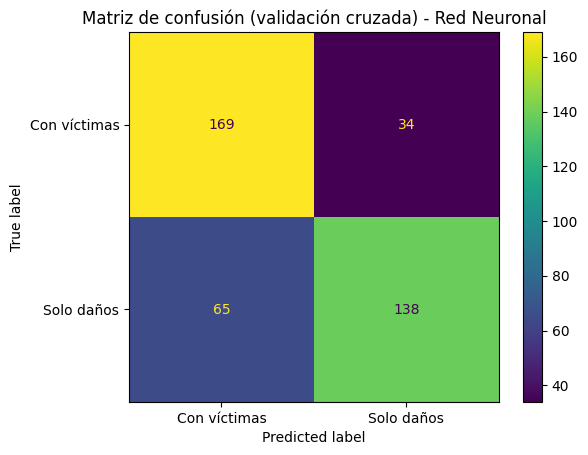

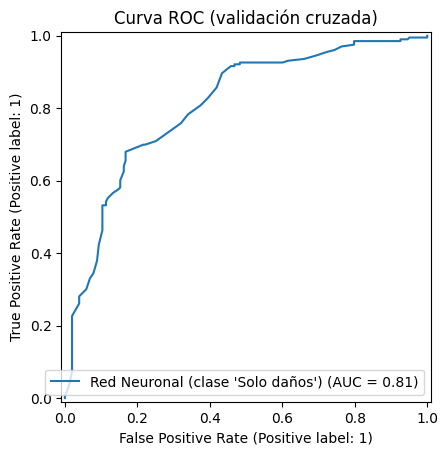

In [56]:
from sklearn import metrics
from sklearn.model_selection import cross_val_predict

clases = labelencoder.classes_
Y_pred_cv = cross_val_predict(construir(mejor).set_params(**mejor_fila['params']), X, Y, cv=cv)

print("Exactitud:", round(metrics.accuracy_score(Y, Y_pred_cv), 3))
print(metrics.classification_report(Y, Y_pred_cv, target_names=clases))

cm = metrics.confusion_matrix(Y, Y_pred_cv)
metrics.ConfusionMatrixDisplay(cm, display_labels=clases).plot()
plt.title(f"Matriz de confusión (validación cruzada) - {mejor}")
plt.show()

# Curva ROC con probabilidades fuera de pliegue
Y_score = cross_val_predict(construir(mejor).set_params(**mejor_fila['params']), X, Y, cv=cv, method='predict_proba')[:, 1]
metrics.RocCurveDisplay.from_predictions(Y, Y_score, name=f"{mejor} (clase '{clases[1]}')")
plt.title("Curva ROC (validación cruzada)")
plt.show()

**Lectura de la evaluación final:** con predicciones fuera de pliegue la exactitud es 0.756. El modelo detecta mejor los accidentes con víctimas (recall 0.83) que los de solo daños (recall 0.68): tiende a clasificar como graves cerca de 1 de cada 3 accidentes que solo dejaron daños. Es un sesgo útil si lo más importante es no pasar por alto los accidentes graves, a cambio de más falsas alarmas. Como los hiperparámetros se eligieron con estos mismos pliegues, estas cifras pueden ser ligeramente optimistas.

In [57]:
# Importancia de variables (si el modelo final la ofrece)
clf_final = modelo_final.named_steps['clf']
if hasattr(clf_final, 'feature_importances_'):
    imp_final = pd.Series(clf_final.feature_importances_, index=X.columns).sort_values(ascending=False)
    imp_final.head(15).sort_values().plot.barh(figsize=(7, 5), title=f'Importancia de variables - {mejor}')
    plt.show()
else:
    print(f"{mejor} no entrega importancias de variables de forma directa.")

Red Neuronal no entrega importancias de variables de forma directa.


In [58]:
import pickle

info_despliegue['nombre_modelo'] = mejor
info_despliegue['metricas_cv'] = {
    'f1_macro': round(float(mejor_fila['mean_test_score']), 3),
    'accuracy': round(float(metrics.accuracy_score(Y, Y_pred_cv)), 3),
}

filename = 'modelo-class-accidentes.pkl'
pickle.dump({'modelo': modelo_final,
             'labelencoder': labelencoder,
             'variables': X.columns.tolist(),
             'info': info_despliegue}, open(filename, 'wb'))
print("Modelo guardado en", filename)

Modelo guardado en modelo-class-accidentes.pkl



# Conclusión general del proyecto

* **Datos:** 406 accidentes de la Comuna Centro de Bucaramanga en 2017, completos (sin nulos, duplicados ni errores lógicos) y con las dos clases balanceadas (203 con víctimas y 203 solo daños).
* **Factores:** de 8 variables candidatas, las que se asocian significativamente con la gravedad son el número de **motos**, el número de **automóviles** y el **barrio**. Más motos se asocia con accidentes con víctimas; más automóviles, con accidentes de solo daños.
* **Modelos:** los seis modelos quedan entre F1 macro 0.71 y 0.75, sin overfitting; el mejor es la Red Neuronal (F1 = 0.751), aunque hay empate técnico con casi todos los demás. El modelo final, con GridSearch, llega a F1 = 0.754 y exactitud de 0.756.
* **Limitaciones:** son pocos datos (406 accidentes, una comuna y un año) y pocas variables, de modo que no se puede esperar más de ~75 % de aciertos. Las columnas de peatones y de otros tipos de vehículo se dejaron fuera (sección 2) y podrían mejorar el desempeño. El modelo sirve para analizar qué condiciones se asocian con accidentes graves, no para decidir casos individuales.
